In [15]:
import pandas as pd
import numpy as np
import sys, os, re, random, json
from pathlib import Path

sys.path.append(os.path.join('..', 'ml-backend'))
from utils.feature_extractor import extract_features, extract_features_batch

random.seed(42)
np.random.seed(42)
print("Import berhasil!")

Import berhasil!


In [16]:
# Load konfigurasi dari config.json
CONFIG_PATH = Path('..') / 'ml-backend' / 'data' / 'config.json'

with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

KEYWORD_SLOT   = config['KEYWORDS']['GAMBLING']
GAMBLING_REGEX = config['REGEX_PATTERNS']['GAMBLING']

print("Config berhasil dimuat!")
print(f"  Keyword phishing : {len(config['KEYWORDS']['PHISHING'])} kata")
print(f"  Keyword gambling : {len(config['KEYWORDS']['GAMBLING'])} kata")
print(f"  Trusted brands   : {len(config['KEYWORDS']['TRUSTED_BRANDS'])} brand")
print(f"  Whitelist domain : {len(config['DOMAINS']['WHITELIST'])} domain")
print(f"  Blacklist domain : {len(config['DOMAINS']['BLACKLIST'])} domain")

Config berhasil dimuat!
  Keyword phishing : 23 kata
  Keyword gambling : 26 kata
  Trusted brands   : 20 brand
  Whitelist domain : 129 domain
  Blacklist domain : 7 domain


In [17]:
# Load data phishing
df_phishing_raw = pd.read_csv('../dataset/phishing_urls.csv')
print(f"Total phishing URL tersedia : {len(df_phishing_raw):,}")
print(f"Kolom                       : {df_phishing_raw.columns.tolist()}")
print()
print("Contoh URL phishing:")
print(df_phishing_raw.head(3).to_string(index=False))

Total phishing URL tersedia : 57,103
Kolom                       : ['url']

Contoh URL phishing:
                                      url
   http://allegrolokalne.pl-590120421.lol
         http://allegro.pl-5903241241.lol
http://allegro-lokalnie.pl-5903241241.lol


In [18]:
df_phishing = pd.DataFrame({
    'url'  : df_phishing_raw['url'],
    'label': 1
})
df_phishing = df_phishing.dropna().drop_duplicates()
df_phishing = df_phishing.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Dataset phishing yang dipakai: {len(df_phishing)} URL")
print("(Diambil secara acak dari 57.103 URL tersedia)")


Dataset phishing yang dipakai: 5000 URL
(Diambil secara acak dari 57.103 URL tersedia)


In [19]:
# Load data legitimate
df_top1m_raw = pd.read_csv('../dataset/top-1m.csv')

print(f"Total legitimate domain tersedia: {len(df_top1m_raw):,}")
print(f"Kolom: {df_top1m_raw.columns.tolist()}")
print()
print("Contoh isi:")
print(df_top1m_raw.head(5).to_string(index=False))

Total legitimate domain tersedia: 1,000,000
Kolom: ['url']

Contoh isi:
         url
  google.com
facebook.com
 youtube.com
   yahoo.com
   baidu.com


In [20]:
# ENRICHMENT URL LEGITIMATE
REALISTIC_PATHS   = config['LEGITIMATE_GENERATE']['REALISTIC_PATHS']
REALISTIC_QUERIES = config['LEGITIMATE_GENERATE']['REALISTIC_QUERIES']

def enrich_legitimate_url(domain):
    scheme = 'https://'

    if random.random() < 0.30:
        return f"{scheme}{domain}"

    path  = random.choice(REALISTIC_PATHS)
    query = random.choice(REALISTIC_QUERIES)

    return f"{scheme}{domain}{path}{query}"

N_LEGITIMATE = 3000

df_legitimate = pd.DataFrame({
    'url'  : [enrich_legitimate_url(d) for d in df_top1m_raw['url'].sample(
                  n=N_LEGITIMATE, random_state=42
              )],
    'label': 0
})

df_legitimate = df_legitimate.dropna().drop_duplicates()

print(f"Dataset legitimate dari top-1m: {len(df_legitimate)} URL")
print(f"(Komposisi: {N_LEGITIMATE} dari top-1m + 2000 institusi = 5000 total aman)")
print()
print("Contoh URL legitimate (setelah enrichment):")
for url in df_legitimate['url'].sample(5, random_state=42).values:
    print(f"  {url}")


Dataset legitimate dari top-1m: 3000 URL
(Komposisi: 3000 dari top-1m + 2000 institusi = 5000 total aman)

Contoh URL legitimate (setelah enrichment):
  https://localdatabase.com/help?sort=desc
  https://sewdaily.com/home?page=1
  https://spiritoftasmania.com.au
  https://pagomaster.com/dashboard?tab=overview
  https://thepanoramaangmokio.com/dashboard?tab=overview


In [21]:
KAMPUS_AC_ID      = config['INSTITUSI_GENERATE']['KAMPUS_AC_ID']
SUBDOMAINS_KAMPUS = config['INSTITUSI_GENERATE']['SUBDOMAINS_KAMPUS']
PEMERINTAH_GO_ID  = config['INSTITUSI_GENERATE']['PEMERINTAH_GO_ID']
SUBDOMAINS_GOV    = config['INSTITUSI_GENERATE']['SUBDOMAINS_GOV']
PATHS_INSTITUSI   = config['INSTITUSI_GENERATE']['PATHS_INSTITUSI']

def generate_institusi_urls(n_target=2500, seed=42):
    random.seed(seed)
    urls = set()

    # URL kampus ac.id
    for kampus in KAMPUS_AC_ID:
        for sub in random.sample(SUBDOMAINS_KAMPUS, min(6, len(SUBDOMAINS_KAMPUS))):
            for path in random.sample(PATHS_INSTITUSI, min(5, len(PATHS_INSTITUSI))):
                url = f"https://{sub}.{kampus}.ac.id{path}" if sub else f"https://{kampus}.ac.id{path}"
                urls.add(url)

    # URL pemerintah go.id
    for instansi in PEMERINTAH_GO_ID:
        for sub in random.sample(SUBDOMAINS_GOV, min(5, len(SUBDOMAINS_GOV))):
            for path in random.sample(PATHS_INSTITUSI, min(4, len(PATHS_INSTITUSI))):
                url = f"https://{sub}.{instansi}.go.id{path}" if sub else f"https://{instansi}.go.id{path}"
                urls.add(url)

    url_list = list(urls)
    random.shuffle(url_list)
    return url_list[:n_target]

df_institusi = pd.DataFrame({
    'url'  : generate_institusi_urls(n_target=2500, seed=42),
    'label': 0,
})

df_institusi = df_institusi.dropna().drop_duplicates(subset=['url'])

print(f"Dataset URL institusi Indonesia: {len(df_institusi)} URL")
print(f"  - Kampus (.ac.id)     : {len(KAMPUS_AC_ID)} kampus")
print(f"  - Pemerintah (.go.id) : {len(PEMERINTAH_GO_ID)} instansi")
print()
print("Contoh URL:")
for url in df_institusi['url'].sample(10, random_state=42).values:
    print(f"  {url}")

Dataset URL institusi Indonesia: 1880 URL
  - Kampus (.ac.id)     : 38 kampus
  - Pemerintah (.go.id) : 37 instansi

Contoh URL:
  https://simrs.pemkot.go.id/wisuda
  https://sipd.kemendikbud.go.id/contact
  https://webmail.ui.ac.id/dosen
  https://simrs.diskominfo.go.id/kontak
  https://akademik.polimdo.ac.id/kontak
  https://pelayanan.setnas.go.id/tentang
  https://unja.ac.id/pengumuman
  https://siakad.unib.ac.id/nilai
  https://mail.kemenkominfo.go.id/perpustakaan
  https://lms.ulm.ac.id/penelitian


In [22]:
# Load data judol
df_gambling_raw = pd.read_csv('../dataset/gambling_urls.csv')

print(f"Total gambling URL di file: {len(df_gambling_raw):,}")
print(f"Kolom: {df_gambling_raw.columns.tolist()}")
print()
print("Contoh URL gambling dari file:")
print(df_gambling_raw.head(5).to_string(index=False))

Total gambling URL di file: 2,910
Kolom: ['url']

Contoh URL gambling dari file:
                          url
       http://data-togel.club
     https://agen-judi.online
http://casino-terpercaya.site
      https://togel-resmi.vip
     http://casino-online.xyz


In [23]:
# Generate url judol tambahan
GAMBLING_KW = config['KEYWORDS']['GAMBLING']

# Template URL judol dibaca dari config.json (GAMBLING_GENERATE)
TLD_JUDOL        = config['GAMBLING_GENERATE']['TLD_JUDOL']
SUFFIX           = config['GAMBLING_GENERATE']['SUFFIX']
JUDOL_PATHS      = config['GAMBLING_GENERATE']['JUDOL_PATHS']
JUDOL_SUBDOMAINS = config['GAMBLING_GENERATE']['JUDOL_SUBDOMAINS']

PROTOCOL = ['http://', 'https://']

def generate_gambling_urls(keywords, n_target=2500, seed=42):
    random.seed(seed)
    urls = set()

    for kw in keywords:
        for tld in TLD_JUDOL:
            for proto in PROTOCOL:
                urls.add(f"{proto}{kw}{tld}")
                for suffix in random.sample(SUFFIX, 3):
                    urls.add(f"{proto}{kw}{suffix}{tld}")
                sub = random.choice(JUDOL_SUBDOMAINS[1:])
                urls.add(f"{proto}{sub}.{kw}{tld}")
                path = random.choice(JUDOL_PATHS[1:])
                urls.add(f"{proto}{kw}{tld}{path}")

    url_list = list(urls)
    random.shuffle(url_list)
    return url_list[:n_target]

TARGET      = 5000
sudah_ada   = len(df_gambling_raw)
perlu_tambah = max(0, TARGET - sudah_ada + 200)

print(f"URL gambling dari file : {sudah_ada}")
print(f"Target total           : {TARGET}")
print(f"Perlu generate tambahan: {perlu_tambah}")
print()

# Generate URL tambahan
urls_tambahan = generate_gambling_urls(GAMBLING_KW, n_target=perlu_tambah, seed=42)

df_tambahan = pd.DataFrame({
    'url'  : urls_tambahan,
    'label': 2
})

df_gambling = pd.concat([
    pd.DataFrame({'url': df_gambling_raw['url'], 'label': 2}),
    df_tambahan
], ignore_index=True)

df_gambling = df_gambling.dropna().drop_duplicates(subset=['url'])
df_gambling = df_gambling.head(TARGET)

print(f"Dataset gambling final : {len(df_gambling)} URL")
print(f"  - Dari file gambling_urls.csv : {min(sudah_ada, TARGET)}")
print(f"  - Generate dari config keyword: {len(df_gambling) - min(sudah_ada, TARGET)}")
print()
print("Contoh URL gambling:")
for url in df_gambling['url'].sample(5, random_state=42).values:
    print(f"  {url}")

URL gambling dari file : 2910
Target total           : 5000
Perlu generate tambahan: 2290

Dataset gambling final : 5000 URL
  - Dari file gambling_urls.csv : 2910
  - Generate dari config keyword: 2090

Contoh URL gambling:
  https://mahjong-ways.com
  http://angka-jitu.top
  https://rtp-live2024.info
  https://togel-sydney.site
  http://slot-jackpot168.site


In [24]:
TARGET = 5000
N_LEGITIMATE = 3000
N_INSTITUSI  = 2000

df_legitimate_sample = df_legitimate.sample(
    n=min(N_LEGITIMATE, len(df_legitimate)), random_state=42
)
df_institusi_sample = df_institusi.sample(
    n=min(N_INSTITUSI, len(df_institusi)), random_state=42
)

df_aman_gabung = pd.concat(
    [df_legitimate_sample, df_institusi_sample],
    ignore_index=True
)
df_aman_gabung = df_aman_gabung.dropna().drop_duplicates(subset=['url'])
df_aman_gabung = df_aman_gabung.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Kelas AMAN total setelah digabung: {len(df_aman_gabung)} URL")
print(f"  - top-1m (situs umum populer)      : {len(df_legitimate_sample)} URL")
print(f"  - Institusi Indonesia (ac.id/go.id) : {len(df_institusi_sample)} URL")
print()

df_phishing_balanced = df_phishing.head(TARGET)
df_gambling_balanced = df_gambling.head(TARGET)

df_all = pd.concat(
    [df_phishing_balanced, df_aman_gabung, df_gambling_balanced],
    ignore_index=True
)

df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total dataset gabungan : {len(df_all)} URL")
print()
print("Distribusi label (harus seimbang ~33% tiap kelas):")
counts    = df_all['label'].value_counts().sort_index()
label_map = {0: 'Aman (0)', 1: 'Phishing (1)', 2: 'Judi Online (2)'}
for label, count in counts.items():
    persen = count / len(df_all) * 100
    bar    = '█' * int(persen / 2)
    print(f"  {label_map[label]:<16}: {count} ({persen:.1f}%) {bar}")

print()
print("✅ Dataset seimbang! Masing-masing kelas ~5.000 URL (33%)")


Kelas AMAN total setelah digabung: 4880 URL
  - top-1m (situs umum populer)      : 3000 URL
  - Institusi Indonesia (ac.id/go.id) : 1880 URL

Total dataset gabungan : 14880 URL

Distribusi label (harus seimbang ~33% tiap kelas):
  Aman (0)        : 4880 (32.8%) ████████████████
  Phishing (1)    : 5000 (33.6%) ████████████████
  Judi Online (2) : 5000 (33.6%) ████████████████

✅ Dataset seimbang! Masing-masing kelas ~5.000 URL (33%)


In [25]:
# Ekstraksi fitur
print("Memulai ekstraksi fitur dari", len(df_all), "URL...")

features_list = extract_features_batch(df_all['url'].tolist())
df_features   = pd.DataFrame(features_list)
df_features['label'] = df_all['label'].values

print(f"✅ Selesai! Shape dataset fitur: {df_features.shape}")
print(f"   Jumlah URL   : {df_features.shape[0]}")
print(f"   Jumlah fitur : {df_features.shape[1] - 1} (+ 1 kolom label)")
print()
print("3 baris pertama:")
print(df_features.head(3).to_string())

Memulai ekstraksi fitur dari 14880 URL...
✅ Selesai! Shape dataset fitur: (14880, 28)
   Jumlah URL   : 14880
   Jumlah fitur : 27 (+ 1 kolom label)

3 baris pertama:
   url_length  has_https  dot_count  hyphen_count  at_count  double_slash  digit_count  domain_length  path_depth  has_query  has_suspicious_tld  has_ip  has_phishing_keyword  has_gambling_keyword  has_brand_spoofing  subdomain_length  subdomain_count  domain_entropy  special_chars  path_length  digit_ratio_url  has_port  has_redirect  consonant_ratio  query_length  query_params  has_fragment  label
0          23          0          1             0         0             0            0              4           1          0                   0       0                     0                     1                   0                 0                0          2.0000              0            7              0.0         0             0           0.7500             0             0             0      2
1          23          1   

In [26]:
# Analisis fitur
label_names = {0: 'Aman', 1: 'Phishing', 2: 'Judi'}

fitur_cek = [
    'url_length', 'dot_count', 'domain_entropy',
    'has_https', 'has_suspicious_tld',
    'has_phishing_keyword', 'has_gambling_keyword',
    'subdomain_count', 'path_length',
]

print("=== Rata-rata Fitur per Kelas ===")
print("(Semakin berbeda antar kelas → semakin berguna untuk model)")
print()

for fitur in fitur_cek:
    print(f"{fitur}:")
    for label, nama in label_names.items():
        rata = df_features[df_features['label'] == label][fitur].mean()
        print(f"  {nama:<10}: {rata:.3f}")
    print()

=== Rata-rata Fitur per Kelas ===
(Semakin berbeda antar kelas → semakin berguna untuk model)

url_length:
  Aman      : 34.845
  Phishing  : 58.021
  Judi      : 23.391

dot_count:
  Aman      : 1.855
  Phishing  : 1.969
  Judi      : 1.077

domain_entropy:
  Aman      : 2.504
  Phishing  : 2.208
  Judi      : 2.895

has_https:
  Aman      : 1.000
  Phishing  : 0.956
  Judi      : 0.505

has_suspicious_tld:
  Aman      : 0.001
  Phishing  : 0.032
  Judi      : 0.431

has_phishing_keyword:
  Aman      : 0.011
  Phishing  : 0.032
  Judi      : 0.010

has_gambling_keyword:
  Aman      : 0.004
  Phishing  : 0.003
  Judi      : 0.950

subdomain_count:
  Aman      : 0.414
  Phishing  : 0.737
  Judi      : 0.074

path_length:
  Aman      : 6.118
  Phishing  : 19.321
  Judi      : 0.742



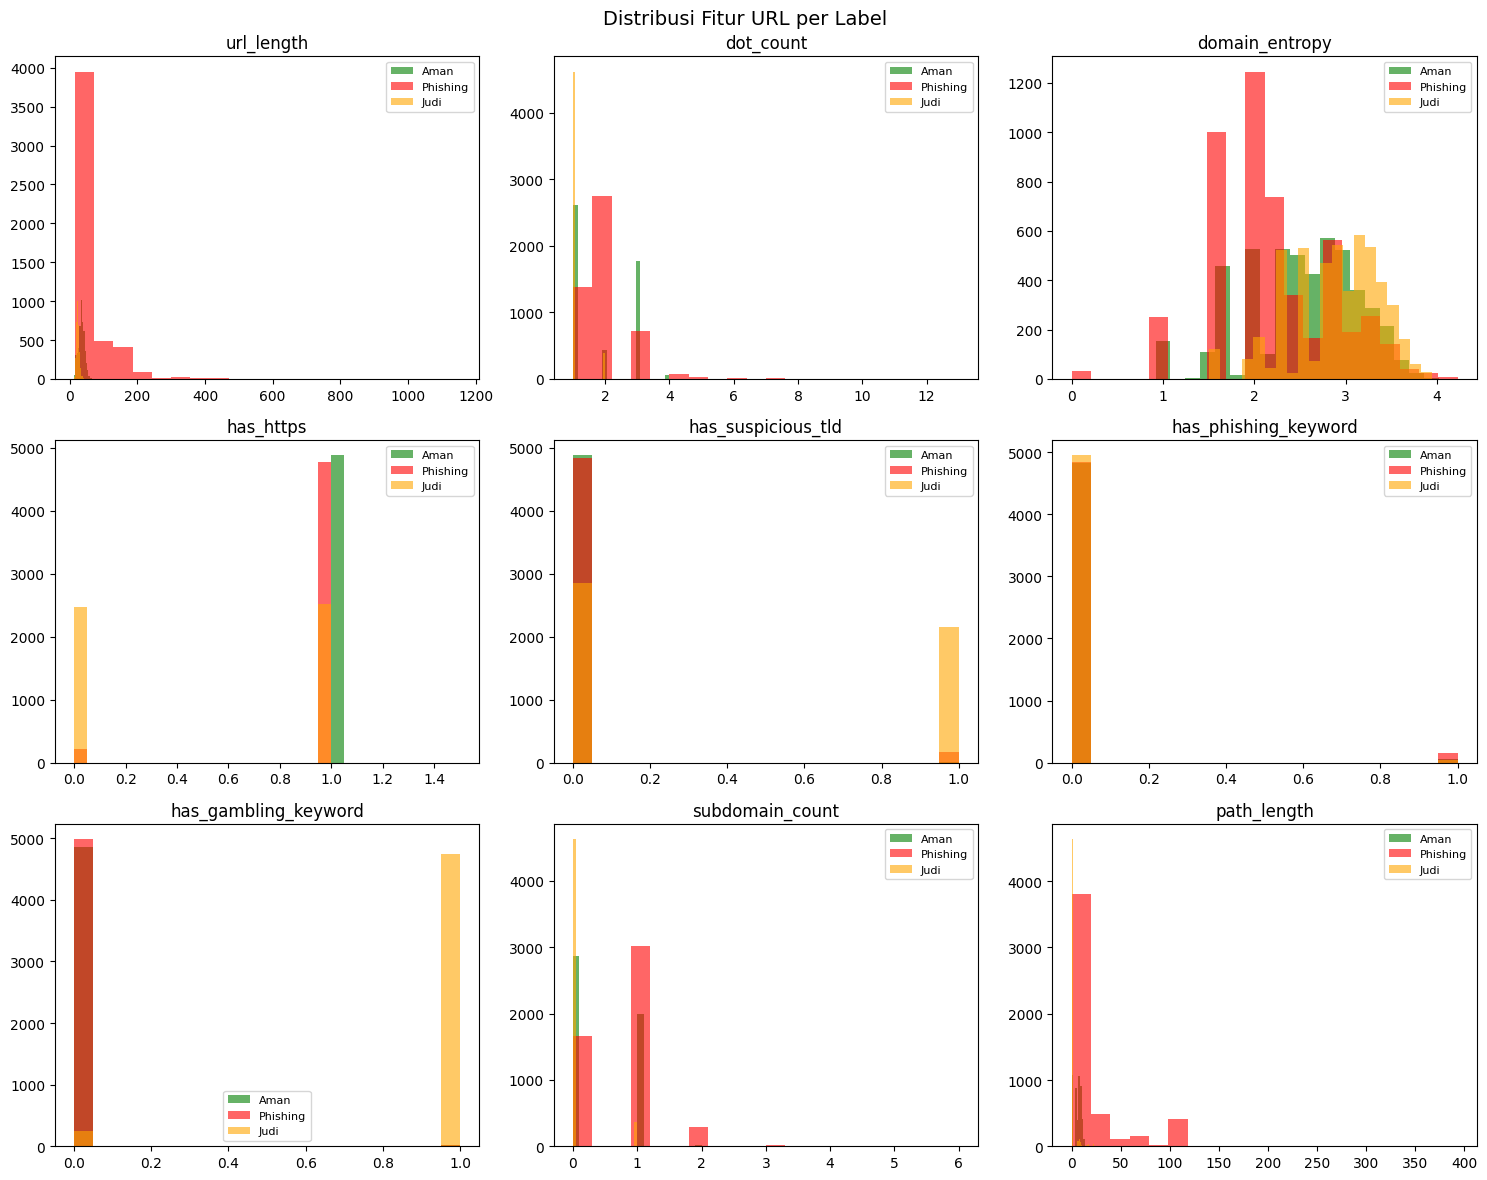

✅ Grafik distribusi fitur disimpan!


In [27]:
import matplotlib.pyplot as plt

colors = {0: 'green', 1: 'red', 2: 'orange'}

fitur_plot = [
    'url_length', 'dot_count', 'domain_entropy',
    'has_https', 'has_suspicious_tld', 'has_phishing_keyword',
    'has_gambling_keyword', 'subdomain_count', 'path_length',
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Fitur URL per Label', fontsize=14)

for idx, fitur in enumerate(fitur_plot):
    ax = axes[idx // 3][idx % 3]
    for label, nama in label_names.items():
        data = df_features[df_features['label'] == label][fitur]
        ax.hist(data, alpha=0.6, label=nama, color=colors[label], bins=20)
    ax.set_title(fitur)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../dataset/feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Grafik distribusi fitur disimpan!")

In [28]:
# Menyimpan features_dataset
SAVE_PATH = '../ml-backend/data/features_dataset.csv'

df_features.to_csv(SAVE_PATH, index=False)

print(f"✅ Dataset fitur berhasil disimpan!")
print(f"   Path  : {SAVE_PATH}")
print(f"   Shape : {df_features.shape}")
print(f"   Kolom : {df_features.columns.tolist()}")
print()

# Verifikasi ulang distribusi di file yang disimpan
df_check = pd.read_csv(SAVE_PATH)
print("Verifikasi distribusi label di file yang disimpan:")
for label, nama in {0:'Aman', 1:'Phishing', 2:'Judi Online'}.items():
    count  = (df_check['label'] == label).sum()
    persen = count / len(df_check) * 100
    print(f"  {nama:<12}: {count} ({persen:.1f}%)")

✅ Dataset fitur berhasil disimpan!
   Path  : ../ml-backend/data/features_dataset.csv
   Shape : (14880, 28)
   Kolom : ['url_length', 'has_https', 'dot_count', 'hyphen_count', 'at_count', 'double_slash', 'digit_count', 'domain_length', 'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip', 'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing', 'subdomain_length', 'subdomain_count', 'domain_entropy', 'special_chars', 'path_length', 'digit_ratio_url', 'has_port', 'has_redirect', 'consonant_ratio', 'query_length', 'query_params', 'has_fragment', 'label']

Verifikasi distribusi label di file yang disimpan:
  Aman        : 4880 (32.8%)
  Phishing    : 5000 (33.6%)
  Judi Online : 5000 (33.6%)
